# G배수지에서 나가는 물 예측
**근데 이제 트랜스포머를 이용한...**


In [2]:
import math
import numpy as np
import torch
import torch.nn as nn  
from torch.utils.data import DataLoader, TensorDataset
from scipy.signal import savgol_filter
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [3]:
print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")
import scipy
print(f"scipy: {scipy.__version__}")
print(f"torch: {torch.__version__}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

numpy: 1.26.4
pandas: 2.1.4
scipy: 1.12.0
torch: 2.2.0+cu121
Using device: cuda


**Params**

In [ ]:
#data slicing
start = 1440 * 0 # +1일차
if (start != 0):
    start = start-2
end = start- 1 + 1439 * 10 #일간
split_rate = 1 - 1/4 

#Sliding window config
window_size=180
forecast_size=15
lead_time=10 #forecast_size 보다 커지면 윈도우 사이에 갭이 생기므로 주의

#Transformer config
d_model = 64
n_head = 8
num_layers = 3

#learning config
epochs=10
batch_size=64
lr=0.0001718750157412344 # < 0.08
dropout=0.5944708972513388

**배수지 데이터 로드 및 처리**

In [44]:
g_resv_flow = pd.read_csv('../../data/rawdata/53.csv')
g_resv_flow.columns = ['id', 'time', 'g_resv_flow', 'drop']
del g_resv_flow['id']
del g_resv_flow['drop']

In [45]:
g_resv_flow_temp = g_resv_flow[start:end].copy()

time = pd.to_datetime(g_resv_flow_temp['time'])
g_resv_flow_temp.loc[:,'time'] = time


**Preprocessing (Savitzky-Golay Filter)**

In [46]:
g_resv_flow_temp.loc[:,'g_resv_flow'] = savgol_filter(g_resv_flow_temp['g_resv_flow'], window_length=31, polyorder=1)

**Data Visualization After Processing**

In [47]:
# fig, ax = plt.subplots(figsize=(15,5))

# #=========g_resv_flow
# #=========g_resv_flow
# #=========g_resv_flow
# ax.plot(time, g_resv_flow_temp['g_resv_flow'], label='OG data', color='red')
# ax.plot(time, g_resv_flow_temp['savgol_smooth'], label='savgol applied', color='blue')

# #=========misc config
# #=========misc config
# #=========misc config
# ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
# ax.set_xlabel('lunch time')
# ax.set_ylabel('G-resv flow')
# ax.legend()

# plt.xticks(rotation=45)

# plt.show()

**날씨 데이터 로드 및 처리**

In [48]:
filenames = [f'../../data/weather/23{month:02d}.csv' for month in range(1, 13)]
w_list = [pd.read_csv(f) for f in filenames]

for w in w_list:
    w.columns = ['time','temperature','precipitate','humidity']

weather = pd.concat(w_list, axis=0).reset_index(drop=True)

time = pd.to_datetime(weather['time'])
weather.loc[:,'time'] = time

In [49]:
weather['precipitate'] = weather['precipitate'].fillna(0)

In [50]:
weather.isna().sum()

time               0
temperature    44723
precipitate        0
humidity       44720
dtype: int64

In [51]:
weather['temperature'] = weather['temperature'].interpolate(method='linear')
weather['humidity'] = weather['humidity'].interpolate(method='linear')

In [52]:
print(weather.shape, g_resv_flow_temp.shape)

(513777, 4) (14389, 2)


**기상청 데이터에 암살자가 있다!!**
- 중복된 timestamp, 특정 timestamp raw 소실 등
- 뭐라도 만들어야되니 일단 inner로 조인해서 없는 데이터는 안쓰는 걸로

In [53]:
df = pd.merge(g_resv_flow_temp, weather, how='inner', on='time')

**Train/Test Split**

In [54]:
split_index = int(len(df) * split_rate)
print(split_index)
df_train = df.iloc[:split_index] 
df_test = df.iloc[split_index:]

10788


**Normalization**
- Only fit scale on train data. Do not fit the test data.

In [55]:
feature_cols = ['g_resv_flow', 'temperature', 'precipitate', 'humidity']
target_cols = ['g_resv_flow'] 

scaler_x = MinMaxScaler(feature_range=(0,1))
X_train_scaled = scaler_x.fit_transform(df_train[feature_cols])
X_test_scaled = scaler_x.transform(df_test[feature_cols])

scaler_y = MinMaxScaler(feature_range=(0,1))
y_train_scaled = scaler_y.fit_transform(df_train[target_cols])
y_test_scaled = scaler_y.transform(df_test[target_cols])

**Create Sliding Window Dataset**

In [56]:
def create_sliding_windows(data, target, window_size, forecast_size, lead_time=0):
    stop_index = len(data) - window_size - forecast_size - lead_time
    X = [data[i:i+window_size] for i in range(stop_index)]
    y = [target[i+window_size+lead_time : i+window_size+forecast_size+lead_time] for i in range(stop_index)]
    
    return np.array(X), np.array(y)


X_train, y_train = create_sliding_windows(data=X_train_scaled, 
                             target=y_train_scaled, 
                             window_size=window_size, 
                             forecast_size=forecast_size,
                             lead_time=lead_time)

X_test, y_test = create_sliding_windows(data=X_test_scaled, 
                             target=y_test_scaled, 
                             window_size=window_size, 
                             forecast_size=forecast_size,
                             lead_time=lead_time)

**Convert Train-Test Dataset into Tensor**

In [57]:
#y_train = np.squeeze(y_train)
#y_test = np.squeeze(y_test)

X_train, X_test, y_train, y_test = torch.FloatTensor(X_train), torch.FloatTensor(X_test), torch.FloatTensor(y_train), torch.FloatTensor(y_test)

**Create Model Class (Transformer)**

**Note on the log-space version of div_term**

$ \begin{aligned} 1 / 10000^{\frac{2i}{d_{model}}} &= 10000^{-\frac{2i}{d_{model}}} \\\\
&= \exp \left(-\frac{2i}{d_{model}} \cdot \ln(10000) \right) \\\\
&= \exp \left({2i} \cdot \frac{\ln(10000)}{d_{model}} \right) 
\end{aligned}$

**Why use this?:**
Working in log-space keeps intermediate values small, preventing blow up of values.
It is a practice for stable computation.

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        #shape(5000,1)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        #shape(d_model // 2,) = shape(32,) = shape(1,32)
        div_term = torch.exp(torch.arange(0, d_model, step=2).float() * (-math.log(10000.0) / d_model))
        #shape(5000,32)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: [Seq_len, Batch_size, d_model]
        return x + self.pe[:x.size(0), :]

class FlowTransformer(nn.Module):
    def __init__(self, input_dim=4, d_model=64, n_head=8, num_layers=3, output_dim=15, dropout=0.1):
        super(FlowTransformer, self).__init__()
        
        # 1. Project 10 features to d_model (64)
        self.input_projection = nn.Linear(input_dim, d_model)
        
        # 2. Add information about time order
        self.pos_encoder = PositionalEncoding(d_model)
        
        # 3. Transformer Encoder Layers
        encoder_layers = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=n_head, 
            dim_feedforward=d_model*4, 
            dropout=dropout,
            batch_first=False # We will permute manually for stability
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        
        # 4. Output head to get 15-min forecast
        self.decoder = nn.Linear(d_model, output_dim)
        
    def forward(self, x):
        # Input x: [Batch, Seq(180), Feat(10)]
        
        # batch_first = False로 해놨기 때문에 sequence가 first dim으로 와야한다.
        # Project and Permute to [Seq, Batch, d_model]
        x = self.input_projection(x) 
        x = x.permute(1, 0, 2) 
        
        # Add Position Encoding
        x = self.pos_encoder(x)
        
        # Pass through Transformer
        output = self.transformer_encoder(x)
        
        # Use the last time step's representation to predict the next 15 mins
        # Alternatively, you can use global average pooling: output.mean(0)
        last_step = output[-1, :, :] 
        
        return self.decoder(last_step)

**Execute Learning**

In [ ]:
#==========Multivariate LSTM with MSE Loss
#==========Multivariate LSTM with MSE Loss
#==========Multivariate LSTM with MSE Loss
#Move the model and train/test data to CUDA
model = FlowTransformer(
    d_model=d_model,
    n_head=n_head,
    num_layers=num_layers,
    output_dim=forecast_size, 
    dropout=dropout
    ).to(device)

# Wrap tensors into a Dataset object
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
# Create the DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) 
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

#mse_criterion = nn.MSELoss() # For MSE
mae_criterion = nn.L1Loss() # Equivalent to mean_absolute_error
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

#Learning
for epoch in range(epochs):
    model.train()

    running_train_loss = 0.0
    #Train
    for batch_X, batch_y in train_loader:
        # Move batch to CUDA
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass (Batch level)
        outputs = model(batch_X)
        loss = mae_criterion(outputs, batch_y.squeeze(-1))
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
    
    # Calculate average training loss for this epoch
    avg_mae_train = running_train_loss / len(train_loader)
    
    # Validation
    all_preds = []
    all_tests = []

    model.eval()
    total_mae_val = 0.0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            # Move ONLY the small batch to the GPU
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            outputs = model(batch_X)

            loss = mae_criterion(outputs, batch_y.squeeze(-1))
            total_mae_val += loss.item()

            # Move back to CPU and convert to list/numpy
            all_preds.append(outputs.cpu())
            all_tests.append(batch_y.cpu())

    average_mae_val = total_mae_val / len(test_loader)
    if(epoch+1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], MAE Loss: {avg_mae_train:.4f}, MAE Val Loss: {average_mae_val:.4f}')

# Concatenate all batches into a single numpy array
y_pred_np = torch.cat(all_preds).numpy()
y_test_np = torch.cat(all_tests).numpy()

c:\Users\user\miniconda3\envs\mypy\Lib\site-packages\torch\nn\modules\transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Epoch [5/10], MAE Loss: 0.0602, MAE Val Loss: 0.0458
Epoch [10/10], MAE Loss: 0.0454, MAE Val Loss: 0.0390


**Recover Original Scale (Denormalize)**

In [60]:
y_pred_original = scaler_y.inverse_transform(y_pred_np.reshape(-1,1)).reshape(y_pred_np.shape)
y_test_original = scaler_y.inverse_transform(y_test_np.reshape(-1,1)).reshape(y_test_np.shape)

**Evaluation**

In [61]:
# fig, ax = plt.subplots(figsize=(15,5), nrows=3, ncols=1, sharex=True)

# #=========temperature
# ax[0].plot(time, weather['temperature'], label='temperature', color='red')
# ax[0].set_ylabel('temperature')
# ax[0].legend()

# #=========precipitate
# ax[1].plot(time, weather['precipitate'], label='precipitate', color='blue')
# ax[1].set_ylabel('precipitate')
# ax[1].legend()

# #=========humidity
# ax[2].plot(time, weather['humidity'], label='humidity', color='skyblue')
# ax[2].set_ylabel('humidity')
# ax[2].legend()
# ax[2].set_xlabel('lunch time')

# #=========misc config
# for a in ax:
#     a.xaxis.set_major_locator(mdates.HourLocator(interval=2))
#     a.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# plt.xticks(rotation=45)

# plt.tight_layout() # Prevents labels from overlapping
# plt.show()

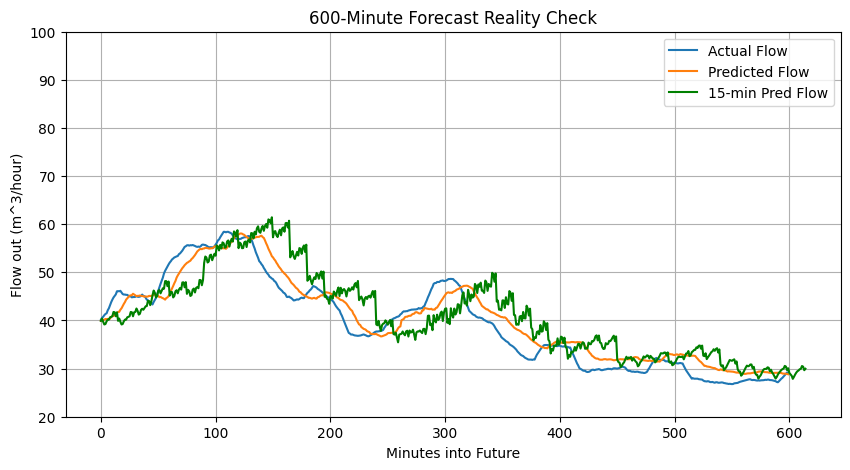

In [62]:
sample_idx0 = 1440 * 0
interval = 60*10 #Max = total interval (minute) * 0.2
sample_idx1 = sample_idx0 + interval

y_test_flattened = y_test_original[:,0].flatten()
y_test_plot = y_test_flattened[sample_idx0 : sample_idx1]

y_pred_flattened = y_pred_original[:,0].flatten()
y_pred_plot = y_pred_flattened[sample_idx0 : sample_idx1]

#Windows
y_pred2_plot = y_pred_original[0]
for i in range(interval//forecast_size):
    y_pred2_plot = np.concatenate((y_pred2_plot,y_pred_original[i*forecast_size]))

plt.figure(figsize=(10, 5))

plt.plot(range(len(y_test_plot)), y_test_plot, label='Actual Flow')#, marker='o')
plt.plot(range(len(y_pred_plot)), y_pred_plot, label='Predicted Flow')#, marker='x')
plt.plot(range(len(y_pred2_plot)), y_pred2_plot, label=f'{forecast_size}-min Pred Flow', color='green')


plt.title(f"{interval}-Minute Forecast Reality Check")
plt.xlabel("Minutes into Future")
plt.ylabel("Flow out (m^3/hour)")
plt.legend()
plt.grid(True)
plt.ylim(20, 100) 
plt.show()

**Data Export**
